<a href="https://colab.research.google.com/github/akanupam/ML_learings/blob/main/Image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import requests

image_path = "handironman.jpg"
img = Image.open(image_path).convert('L')

matrix = np.array(img)
print("Image marrix shape: ", matrix.shape)
print("Image matrix first 5X5:\n", matrix[:5,:5])

Image marrix shape:  (490, 735)
Image matrix first 5X5:
 [[70 71 72 72 72]
 [70 71 72 72 73]
 [71 71 72 73 73]
 [71 71 72 73 73]
 [71 72 73 73 73]]


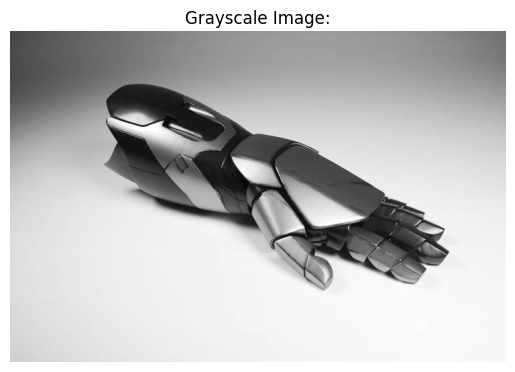

In [10]:
plt.imshow(matrix, cmap='gray')
plt.title("Grayscale Image:")
plt.axis('off')
plt.show()


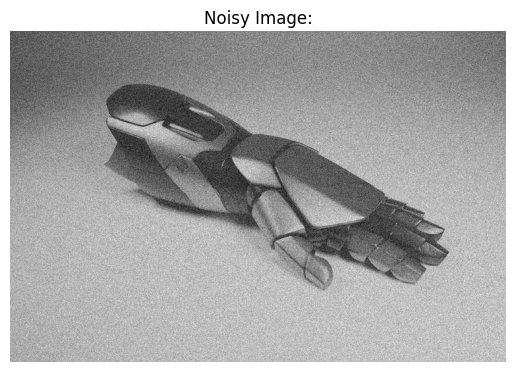

[[ 72.4499212   77.07341196  98.60905294 ... 145.32577163 123.79745776
  165.0630069 ]
 [ 72.23640923  71.46439827  86.36257173 ... 123.53449585 134.67843702
   85.25897169]
 [ 79.67269294  58.82548332  31.81601776 ... 109.75443473 109.70837719
   88.82962031]
 ...
 [168.94042671 215.76407789 216.74062611 ... 242.80703537 222.43230554
  248.50600279]
 [226.61829043 212.40719632 247.15634908 ... 262.59555734 203.08687098
  240.26451143]
 [201.98814836 189.56937034 222.33264209 ... 265.43992174 221.18714182
  203.2890874 ]]


In [19]:
img_array = np.array(img, dtype=np.float32)
#making the noise
noise = np.random.normal(0,25,img_array.shape)
noisy_image = img_array+noise

plt.imshow(noisy_image, cmap='gray')
plt.title("Noisy Image:")
plt.axis('off')
plt.show()

print(noisy_image)

noisy_image = noisy_image.astype(np.uint8)
# print(noisy_image)
noisy_image = Image.fromarray(noisy_image)

# plt.imshow(noisy_image, cmap='gray')
# plt.title("uint8 noisy image:")
# plt.axis('off')
# plt.show()


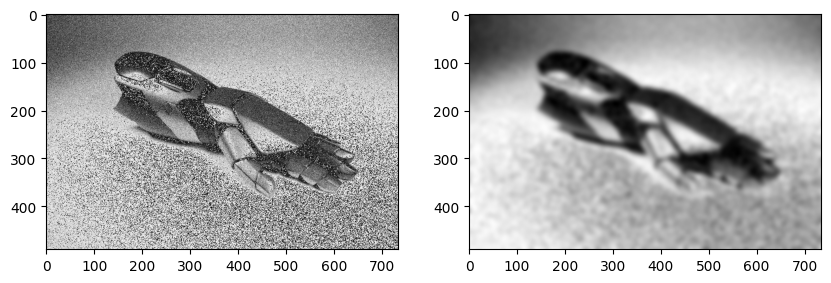

In [27]:
clear_image = noisy_image.filter(ImageFilter.GaussianBlur(radius=5))

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.imshow(noisy_image, cmap='gray')
ax2.imshow(clear_image, cmap='gray')
plt.show()

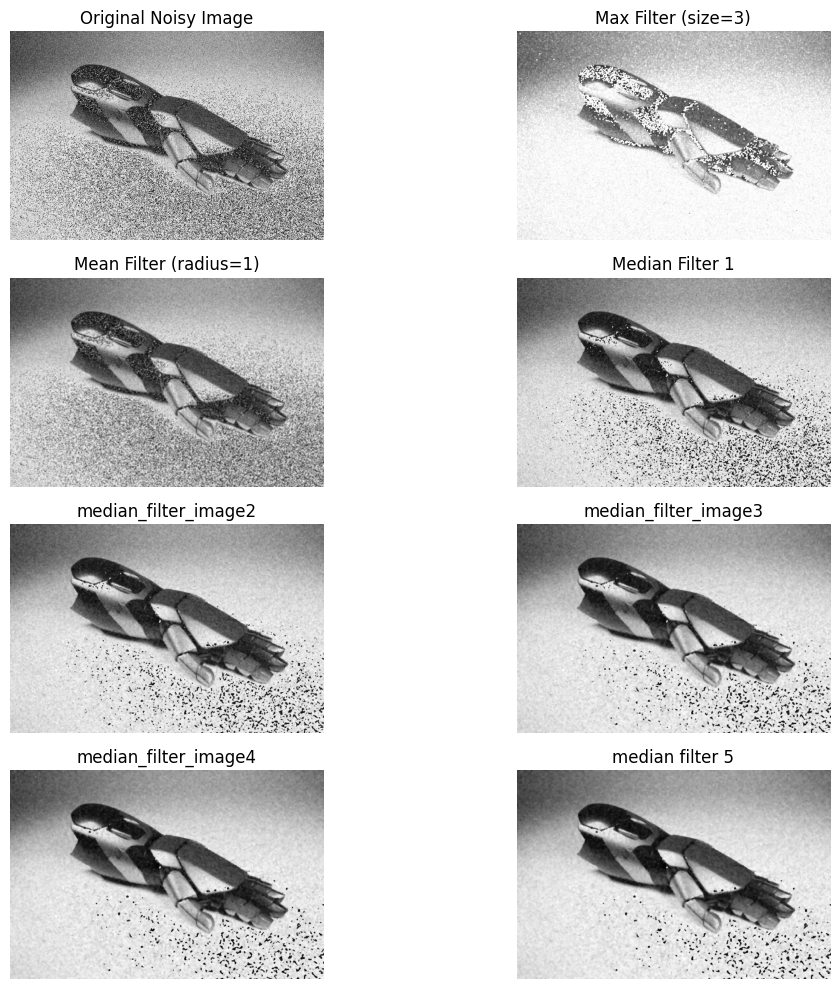

In [48]:
min_filter_image = noisy_image.filter(ImageFilter.MinFilter(size=3))
max_filter_image = noisy_image.filter(ImageFilter.MaxFilter(size=3))
mean_filter_image = noisy_image.filter(ImageFilter.BoxBlur(radius=1))
median_filter_image = noisy_image.filter(ImageFilter.MedianFilter(size=3))
median_filter_image2 = median_filter_image.filter(ImageFilter.MedianFilter(size=3))
median_filter_image3 = median_filter_image2.filter(ImageFilter.MedianFilter(size=3))
median_filter_image4 = median_filter_image3.filter(ImageFilter.MedianFilter(size=3))
median_filter_image5 = median_filter_image4.filter(ImageFilter.MedianFilter(size=3))
fig, axes = plt.subplots(4,2, figsize=(12,10))
filters = [noisy_image,  max_filter_image, mean_filter_image, median_filter_image, median_filter_image2, median_filter_image3, median_filter_image4,median_filter_image5]
titles = ['Original Noisy Image',  'Max Filter (size=3)', 'Mean Filter (radius=1)', 'Median Filter 1','median_filter_image2', 'median_filter_image3', 'median_filter_image4','median filter 5' ]

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i], cmap='gray')
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()